## Set-Up


In [2]:
!pip install tifffile imaris_ims_file_reader numpy matplotlib opencv-python

In [1]:
from datetime import datetime
from skimage import exposure
from tifffile import tifffile
from imaris_ims_file_reader import ims
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt
import numpy as np

## Extracting Images

In [14]:
count = 4 #What number of image set it is
res = 2 # 0 - 5, Not the highest resolution to help segmentation work better
n_slices = 10 #Number of images
thickness = 30

path = "/Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims" #Path to Imaris file

In [4]:
# Apply gamma correction to the generated images.
def gamma_corr(img, g=1.3):
    return exposure.adjust_gamma(img, g)

# Save image and do a gamma correction in between as the images are too dark.
def save_cross(array, filename):
    slice_float = array.astype(np.float32) # Convert to a float32

    min_val = 0
    max_val = 1500
    slice_float = np.clip(slice_float, min_val, max_val)
    
    norm = (slice_float - min_val) / (max_val - min_val)
    
    #corrected = gamma_corr(norm)

    slice_uint16 = (norm * 65535).astype(np.uint16) #Convert to uint16 again

    tifffile.imwrite(filename, slice_uint16, resolution=(300, 300), resolutionunit="inch") # Create image
    print(f"Saved: {filename}")

Started at: 21:05:46

Opening readonly file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 

Closing file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 


Data shape: (1, 1, 1118, 1499, 1869)

Slice 1 started at: 21:05:46
Slice 1 Shape xy: (1499, 1869)
Saved: NeuN_Af647_3.6x_0_xy_4.tiff
Slice 1 Shape xz: (1118, 1869)
Saved: NeuN_Af647_3.6x_0_xz_4.tiff
Slice 1 Shape yz: (1118, 1499)
Saved: NeuN_Af647_3.6x_0_yz_4.tiff
Slice 1 finished at: 21:05:49
Total slice time: 0:00:03.560474


Slice 2 started at: 21:05:49
Slice 2 Shape xy: (1499, 1869)
Saved: NeuN_Af647_3.6x_1_xy_4.tiff
Slice 2 Shape xz: (1118, 1869)
Saved: NeuN_Af647_3.6x_1_xz_4.tiff
Slice 2 Shape yz: (1118, 1499)
Saved: NeuN_Af647_3.6x_1_yz_4.tiff
Slice 2 finished at: 21:05:53
Total slice time: 0:00:03.887994


Slice 3 started at: 21:05:53
Slice 3 Shape xy: (1499, 1869)
Saved: NeuN_Af647_3.6x_2_xy_4.tiff
Slice 3 Shape xz: (1118, 1869)
Saved: NeuN_Af647_3.6x_2_xz_4.tiff
Slice 3 Shape yz: (1118, 1499)
Saved: NeuN_Af64

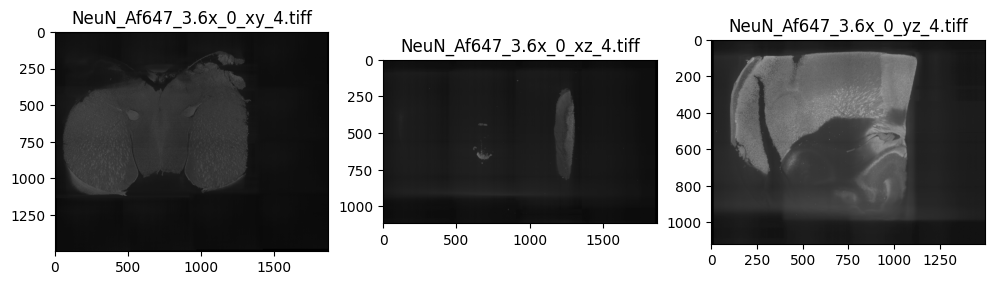

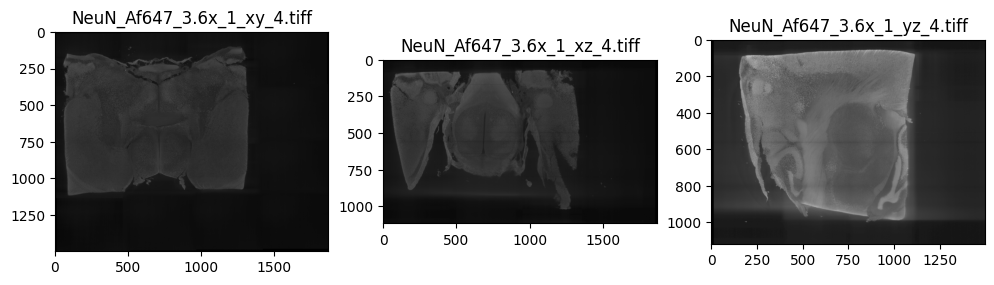

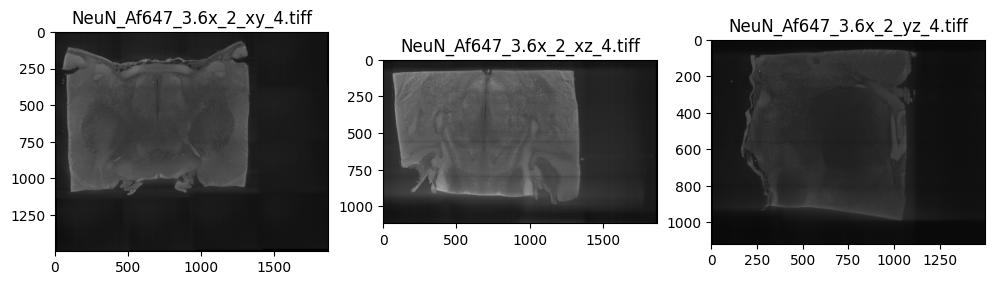

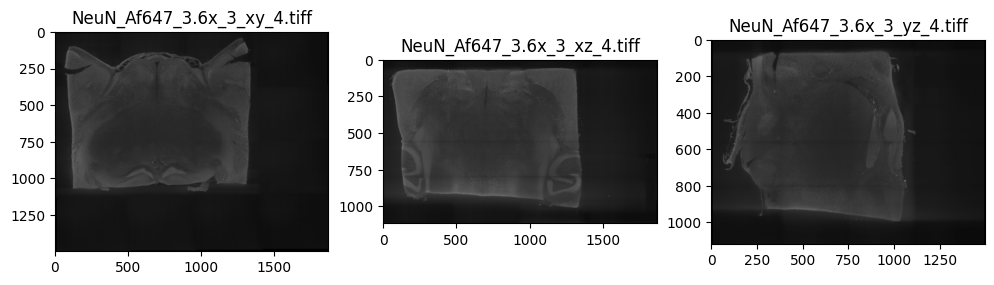

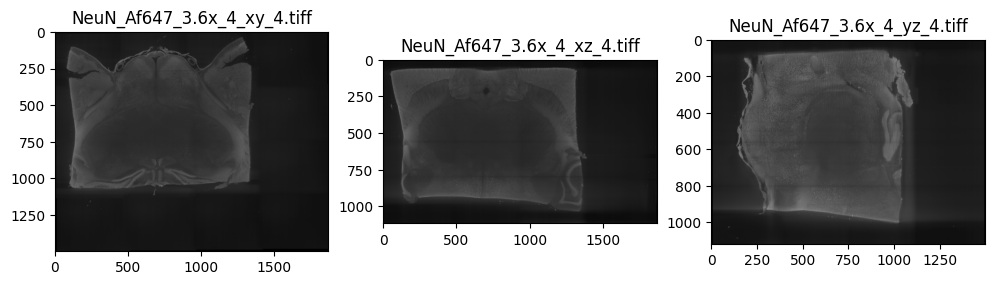

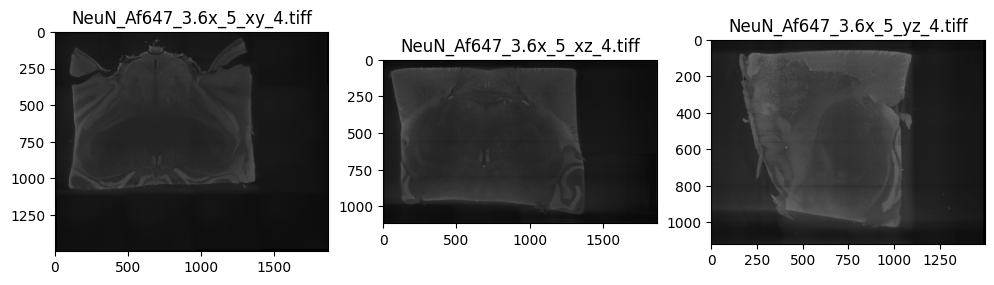

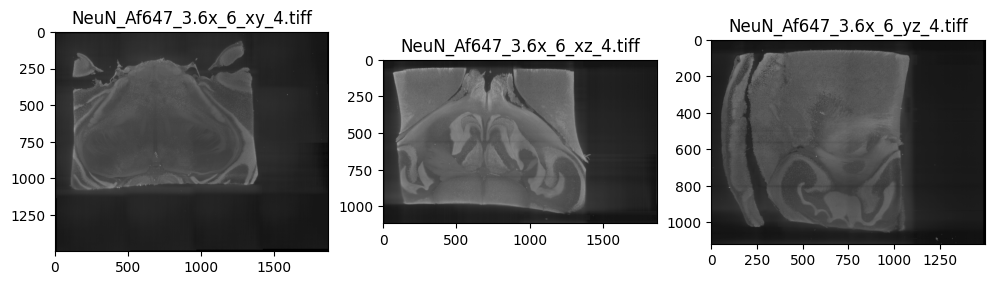

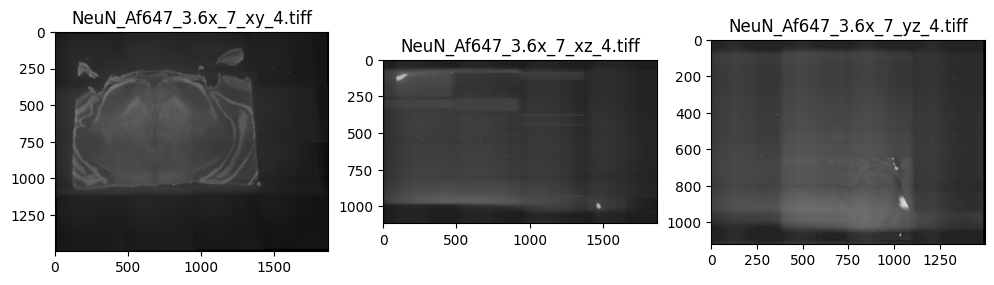

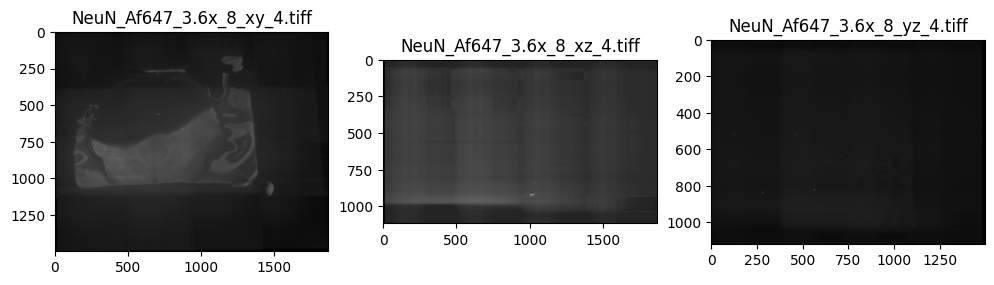

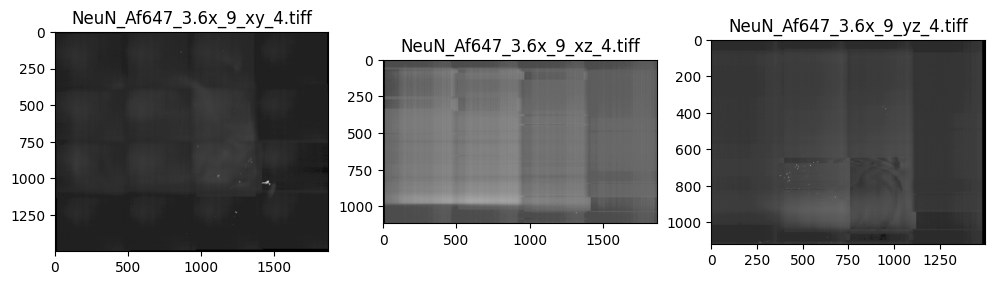

In [15]:
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

# ims_data[Time, Channel, z, Y, X]
ims_data = ims(path, ResolutionLevelLock=res)

print(f"\nData shape: {ims_data.shape}")

z_splits = [i * ims_data.shape[2] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
y_splits = [i * ims_data.shape[3] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
x_splits = [i * ims_data.shape[4] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes

for i in range(n_slices):
    start_t = datetime.now()
    print(f"\nSlice {(i+1)} started at: {start_t.strftime('%H:%M:%S')}")

    mid_z = (z_splits[i] + z_splits[i+1]) // 2  # midpoint of this slice
    z_end = min(mid_z + thickness, ims_data.shape[2])  # clamp to actual z dimension
    slice_xy = ims_data[0, :, mid_z:z_end, :, :].max(axis=0)  # shape: (C, z, Y, X)
    
    mid_y = (y_splits[i] + y_splits[i+1]) // 2  # midpoint of this slice
    y_end = min(mid_y + thickness, ims_data.shape[3])  # clamp to actual Y dimension
    slice_xz = ims_data[0, :, :, mid_y:y_end, :].max(axis=1)  # shape: (C, z, Y, X)
    
    mid_x = (x_splits[i] + x_splits[i+1]) // 2  # midpoint of this slice
    x_end = min(mid_x + thickness, ims_data.shape[4])  # clamp to actual X dimension
    slice_yz = ims_data[0, :, :, :, mid_x:x_end].max(axis=2)  # shape: (C, z, Y, X)


    print(f"Slice {(i+1)} Shape xy: {slice_xy.shape}")
    save_cross(slice_xy[::-1], f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff") #Create Image
    
    print(f"Slice {(i+1)} Shape xz: {slice_xz.shape}")
    save_cross(slice_xz[::-1], f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff") #Create Image
    
    print(f"Slice {(i+1)} Shape yz: {slice_yz.shape}")
    save_cross(slice_yz[::-1], f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff") #Create Image
    
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(gamma_corr(slice_xy,0.3), cmap='gray')
    ax[0].set_title(f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff")
    ax[1].imshow(gamma_corr(slice_xz,0.3), cmap='gray')
    ax[1].set_title(f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff")
    ax[2].imshow(gamma_corr(slice_yz,0.3), cmap='gray')
    ax[2].set_title(f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff")

    del slice_xy #Delete array from memory
    del slice_xz #Delete array from memory
    del slice_yz #Delete array from memory

    end_t = datetime.now()
    print(f"Slice {(i+1)} finished at: {end_t.strftime('%H:%M:%S')}")
    print(f"Total slice time: {end_t - start_t}\n")

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")

In [ ]:
"""
Extract an oblique plane from a 3D volume at any angle.

volume_3d: np.array (Z, Y, X)
normal: tuple (nz, ny, nx) — direction perpendicular to the cut plane
center: tuple (z, y, x) — point the plane passes through. Defaults to volume center.
size: output image resolution (size x size pixels)
thickness: number of planes to max-project through

Returns: 2D image (size, size)
"""
def oblique_slice(volume_3d, normal=(1, 1, 1), center=None, size=512, thickness=1):
    z, y, x = volume_3d.shape

    if center is None:
        center = np.array([z/2, y/2, x/2])
    else:
        center = np.array(center)

    # Normalize the normal vector
    normal = np.array(normal, dtype=np.float32)
    normal /= np.linalg.norm(normal)

    # Build two orthogonal vectors in the plane (u and v axes)
    # Find a vector not parallel to normal
    if abs(normal[0]) < 0.9:
        ref = np.array([1, 0, 0])
    else:
        ref = np.array([0, 1, 0])

    u = np.cross(normal, ref)
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    v /= np.linalg.norm(v)

    # Build grid of sample points in the oblique plane
    half = size // 2
    pu = np.linspace(-half, half, size)
    pv = np.linspace(-half, half, size)
    pu_grid, pv_grid = np.meshgrid(pu, pv)  # (size, size)

    result = np.zeros((size, size), dtype=np.float32)

    offsets = np.arange(thickness) - thickness // 2

    for t in offsets:
        # Points in 3D space along the oblique plane + thickness offset
        points = (center[:, None, None]
                  + pu_grid[None] * u[:, None, None]
                  + pv_grid[None] * v[:, None, None]
                  + t * normal[:, None, None])  # (3, size, size)

        z_coords = np.clip(points[0].ravel(), 0, z-1)
        y_coords = np.clip(points[1].ravel(), 0, y-1)
        x_coords = np.clip(points[2].ravel(), 0, x-1)

        sampled = map_coordinates(
            volume_3d.astype(np.float32),
            [z_coords, y_coords, x_coords],
            order=1
        ).reshape(size, size)

        result = np.maximum(result, sampled)  # max project through thickness

    return result

Text(0.5, 1.0, 'NeuN_Af647_3.6x_5_Oblique_4.tiff')

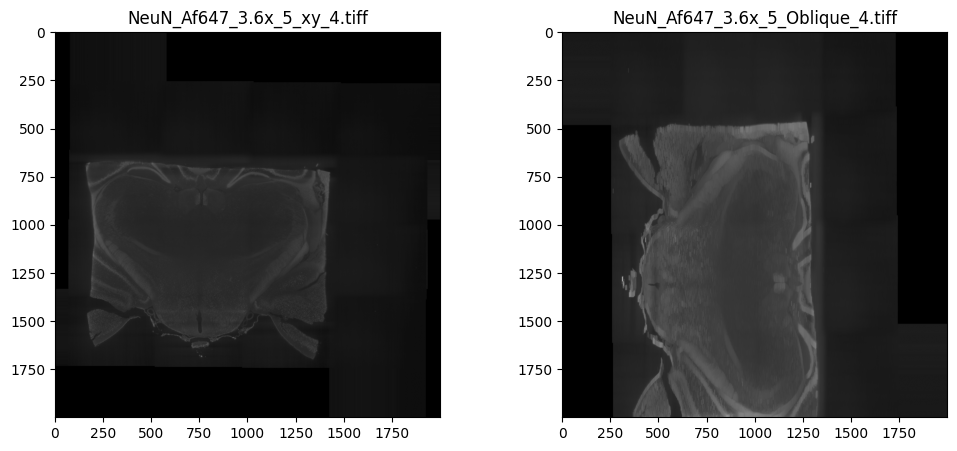

In [30]:
#USE THE ARRAY
i = 5
mid_z = (z_splits[i] + z_splits[i+1]) // 2
z_end = min(mid_z + thickness, ims_data.shape[2])
vol = np.array(ims_data[0, 0, mid_z:z_end, :, :])

# Straight cuts — normal aligned to each axis
diag_xy = oblique_slice(vol, normal=(1, 0, 0), size=2000)   # standard XY
#diag_xz = oblique_slice(vol, normal=(0, 1, 0), size=1080)   # standard XZ
#diag_yz = oblique_slice(vol, normal=(0, 0, 1), size=1080)   # standard YZ

# True oblique — any angle you want
diag_oblique = oblique_slice(vol, normal=(1, 0, 0.75), size=2000, thickness=thickness)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(gamma_corr(diag_xy,0.3), cmap='gray')
ax[0].set_title(f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff")
#ax[1].imshow(gamma_corr(diag_xz,0.3), cmap='gray')
#ax[1].set_title(f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff")
#ax[2].imshow(gamma_corr(diag_yz,0.3), cmap='gray')
#ax[2].set_title(f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff")
ax[1].imshow(gamma_corr(diag_oblique,0.3)[::-1], cmap='gray')
ax[1].set_title(f"NeuN_Af647_3.6x_{i}_Oblique_{count}.tiff")

Started at: 14:25:10

Opening readonly file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 

Closing file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 


Data shape: (1, 1, 559, 749, 934)

Slice 1 started at: 14:25:10
Slice 1 Shape xy: (100, 934)
Saved: NeuN_Af647_3.6x_0_diag_xy_4.tiff
Slice 1 Shape xz: (100, 934)
Saved: NeuN_Af647_3.6x_0_diag_xz_4.tiff
Slice 1 Shape yz: (100, 749)
Saved: NeuN_Af647_3.6x_0_diag_yz_4.tiff
Slice 1 finished at: 14:25:12
Total slice time: 0:00:01.867277


Slice 2 started at: 14:25:12
Slice 2 Shape xy: (100, 934)
Saved: NeuN_Af647_3.6x_1_diag_xy_4.tiff
Slice 2 Shape xz: (100, 934)
Saved: NeuN_Af647_3.6x_1_diag_xz_4.tiff
Slice 2 Shape yz: (100, 749)
Saved: NeuN_Af647_3.6x_1_diag_yz_4.tiff
Slice 2 finished at: 14:25:14
Total slice time: 0:00:01.558695


Slice 3 started at: 14:25:14
Slice 3 Shape xy: (100, 934)
Saved: NeuN_Af647_3.6x_2_diag_xy_4.tiff
Slice 3 Shape xz: (100, 934)
Saved: NeuN_Af647_3.6x_2_diag_xz_4.tiff
Slice 3 Shape yz: (100, 74

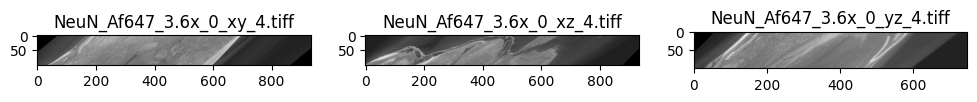

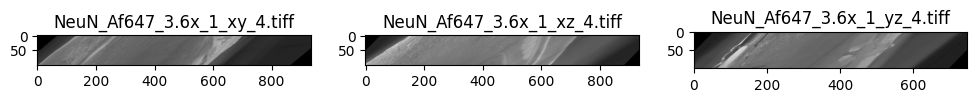

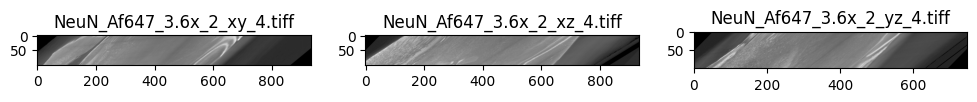

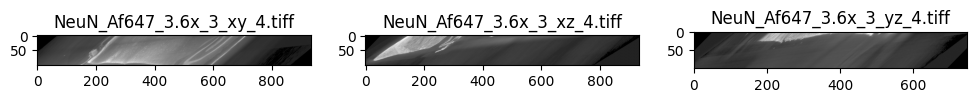

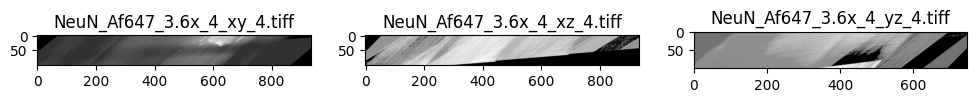

In [ ]:
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

# ims_data[Time, Channel, Z, Y, X]
ims_data = ims(path, ResolutionLevelLock=res)

print(f"\nData shape: {ims_data.shape}")

z_splits = [i * ims_data.shape[2] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
y_splits = [i * ims_data.shape[3] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
x_splits = [i * ims_data.shape[4] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes

for i in range(n_slices):
    start_t = datetime.now()
    print(f"\nSlice {(i+1)} started at: {start_t.strftime('%H:%M:%S')}")

    mid_z = (z_splits[i] + z_splits[i+1]) // 2  # midpoint of this slice
    z_end = min(mid_z + thickness, ims_data.shape[2])  # clamp to actual Z dimension
    diag_xy = corner_diagonal_band(ims_data[0, :, mid_z:z_end, :, :], thickness)
    
    mid_y = (y_splits[i] + y_splits[i+1]) // 2  # midpoint of this slice
    y_end = min(mid_y + thickness, ims_data.shape[3])  # clamp to actual Y dimension
    diag_xz = corner_diagonal_band(ims_data[0, :, :, mid_y:y_end, :], thickness)
    
    mid_x = (x_splits[i] + x_splits[i+1]) // 2  # midpoint of this slice
    x_end = min(mid_x + thickness, ims_data.shape[4])  # clamp to actual X dimension
    diag_yz = corner_diagonal_band(ims_data[0, :, :, :, mid_x:x_end], thickness)


    print(f"Slice {(i+1)} Shape xy: {diag_xy.shape}")
    save_cross(diag_xy[np.newaxis, ::-1], f"NeuN_Af647_3.6x_{i}_diag_xy_{count}.tiff")
    
    print(f"Slice {(i+1)} Shape xz: {diag_xz.shape}")
    save_cross(diag_xz[np.newaxis, ::-1], f"NeuN_Af647_3.6x_{i}_diag_xz_{count}.tiff")
    
    print(f"Slice {(i+1)} Shape yz: {diag_yz.shape}")
    save_cross(diag_yz[np.newaxis, ::-1], f"NeuN_Af647_3.6x_{i}_diag_yz_{count}.tiff")
    
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(gamma_corr(diag_xy,0.3), cmap='gray')
    ax[0].set_title(f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff")
    ax[1].imshow(gamma_corr(diag_xz,0.3), cmap='gray')
    ax[1].set_title(f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff")
    ax[2].imshow(gamma_corr(diag_yz,0.3), cmap='gray')
    ax[2].set_title(f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff")

    del diag_xy #Delete array from memory
    del diag_xz #Delete array from memory
    del diag_yz #Delete array from memory

    end_t = datetime.now()
    print(f"Slice {(i+1)} finished at: {end_t.strftime('%H:%M:%S')}")
    print(f"Total slice time: {end_t - start_t}\n")

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")